 # Logistic Regression with cleaned text + structured features


In [1]:

import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import hstack, csr_matrix

In [2]:
# 1. Load the cleaned data
with open("acled_cleaned.pkl", "rb") as f:
    df = pickle.load(f)
# 2. Prepare structured features
# Clip fatalities to reduce outlier impact
df['fatalities_clipped'] = df['fatalities'].clip(upper=50)

# Length of event description
df['desc_length'] = df['clean_description'].apply(lambda x: len(x.split()))

# Use already one-hot encoded inter1 and interaction columns
structured_features = df[['fatalities_clipped', 'desc_length'] + 
                         [col for col in df.columns if col.startswith('actor_type_') or col.startswith('interaction_')]]

# Ensure structured features are in float format for sparse matrix compatibility
# Ensure all values are float and convert to sparse format
structured_features = structured_features.astype(np.float64)
structured_matrix = csr_matrix(structured_features)

In [3]:
# 3. Text Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df['clean_description'])

# 4. Combine structured + text features
from scipy.sparse import hstack
X_combined = hstack([X_text, structured_features.values])

# 5. Labels
y = df['event_type'].astype("category")



In [4]:
# 6. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

# 7. Train model
clf = LogisticRegression(max_iter=2000, solver='saga', n_jobs=-1)
clf.fit(X_train, y_train)





C:\Users\pablo\anaconda3\envs\acled\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=2000, n_jobs=-1, solver='saga')

In [5]:
# 8. Predict and evaluate
y_pred = clf.predict(X_test)



Classification Report:

                            precision    recall  f1-score   support

                   Battles       0.86      0.96      0.91       563
Explosions/Remote violence       0.94      0.89      0.91      1062
                  Protests       1.00      1.00      1.00      1492
                     Riots       0.99      1.00      0.99       186
    Strategic developments       0.83      0.70      0.76       314
Violence against civilians       0.87      0.92      0.90       383

                  accuracy                           0.94      4000
                 macro avg       0.91      0.91      0.91      4000
              weighted avg       0.94      0.94      0.94      4000



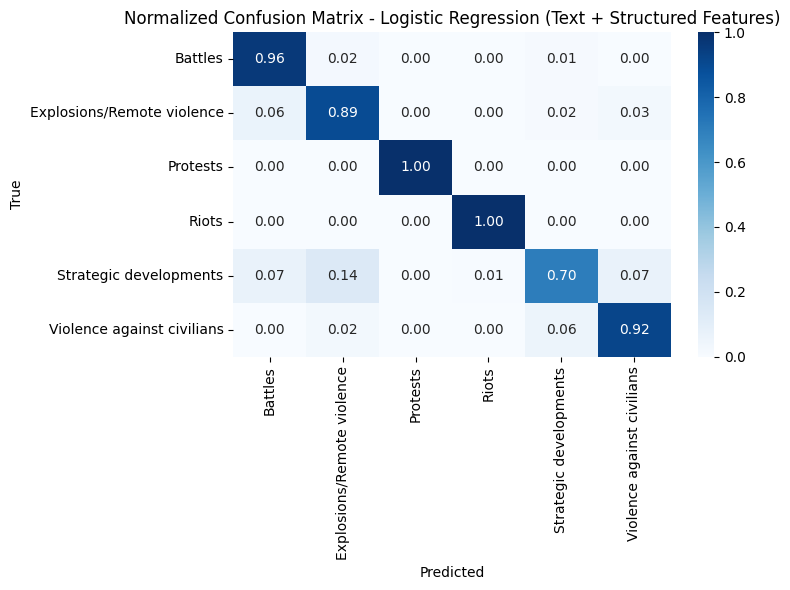

In [6]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=y.cat.categories))

# Normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=y.cat.categories, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=y.cat.categories,
            yticklabels=y.cat.categories)
plt.title("Normalized Confusion Matrix - Logistic Regression (Text + Structured Features)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## Exploring L1-Regularized Logistic Regression for Feature Selection
As the logistic regression model with combined structured and text features was not converging reliably, let´s explore an alternative approach using L1-regularized logistic regression. This method helps identify and automatically eliminate structured features that do not meaningfully contribute to the classification task by shrinking their coefficients to zero.

By focusing only on features that survive this regularization process, we aim to reduce noise, improve model stability, and better understand which structured elements (if any) are useful in predicting event types.

In [7]:
from sklearn.preprocessing import StandardScaler

# Scale structured features only (text vector is already normalized)
scaler = StandardScaler(with_mean=False)  # with_mean=False to support sparse matrices
structured_scaled = scaler.fit_transform(structured_matrix)

In [8]:
# Combine text and structured features
X_l1 = hstack([X_text, structured_scaled])

# Train/test split
X_train_l1, X_test_l1, y_train_l1, y_test_l1 = train_test_split(X_l1, y, test_size=0.2, random_state=42)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning

# We're using the same combined features and labels from earlier
# Let's test a range of C values (lower C = more regularization)
C_values = np.logspace(-3, 0.5, 5)
coefs = []  # don't wrap this in np.array

for C in C_values:
    clf = LogisticRegression(
        penalty='l1',
        C=C,
        solver='saga',
        multi_class='multinomial',
        max_iter=300,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    coefs.append(clf.coef_)  # this stays as a list of arrays
    
# Stack into a matrix so each row is a model, each column a feature
coefs2 = np.vstack(coefs)

# Plot time 📈 — show how feature weights evolve as C changes
plt.figure(figsize=(14, 6))
for i in range(coefs2.shape[1]):
    plt.plot(C_values, coefs2[:, i], lw=1)

plt.xscale('log')
plt.xlabel("C (Inverse Regularization Strength - log scale)")
plt.ylabel("Coefficient Value")
plt.title("How L2 Shrinks Coefficients As Regularization Increases")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

C:\Users\pablo\anaconda3\envs\acled\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\pablo\anaconda3\envs\acled\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\pablo\anaconda3\envs\acled\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\pablo\anaconda3\envs\acled\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\pablo\anaconda3

KeyboardInterrupt: 

In [21]:
print("Model diagnostics:\n")
print(f"• Number of target classes: {len(clf.classes_)}")
print(f"• Solver used: {clf.solver}")
print(f"• Inferred multi_class setting: {'multinomial' if clf.classes_.shape[0] > 2 and clf.coef_.ndim == 2 else 'ovr (one-vs-rest)'}")

# Optional: print out shape of coefficients
print(f"• Coefficients shape: {clf.coef_.shape}")


Model diagnostics:

• Number of target classes: 6
• Solver used: lbfgs
• Inferred multi_class setting: multinomial
• Coefficients shape: (6, 5051)


In [22]:
print("Top features retained at different regularization strengths (C):\n")

feature_names = np.array(
    vectorizer.get_feature_names_out().tolist() + structured_features.columns.tolist()
)

for c_val, coef in zip(C_values, coefs):
    if coef.ndim != 2:
        print(f"⚠️ Skipping C = {c_val:.3f} due to unexpected shape: {coef.shape}\n")
        continue

    # Average across classes to get a single importance score per feature
    avg_coef = np.mean(np.abs(coef), axis=0)

    # Get indices where coefficients are non-zero
    non_zero_indices = np.where(avg_coef != 0)[0]

    selected_features = feature_names[non_zero_indices]
    
    print(f"C = {c_val:.3f} ({len(selected_features)} features retained)")
    print("→", ", ".join(selected_features[:10]), "\n")


Top features retained at different regularization strengths (C):

C = 0.001 (5051 features retained)
→ aa, aadayseh, aalma, aamb, aap, aarakshan, aasu, aba, abandon, abasan 

C = 0.007 (5051 features retained)
→ aa, aadayseh, aalma, aamb, aap, aarakshan, aasu, aba, abandon, abasan 

C = 0.056 (5051 features retained)
→ aa, aadayseh, aalma, aamb, aap, aarakshan, aasu, aba, abandon, abasan 

C = 0.422 (5051 features retained)
→ aa, aadayseh, aalma, aamb, aap, aarakshan, aasu, aba, abandon, abasan 

C = 3.162 (5051 features retained)
→ aa, aadayseh, aalma, aamb, aap, aarakshan, aasu, aba, abandon, abasan 



In [9]:
# L1-regularized logistic regression
clf_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=500, n_jobs=-1)
clf_l1.fit(X_train_l1, y_train_l1)



C:\Users\pablo\anaconda3\envs\acled\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=500, n_jobs=-1, penalty='l1', solver='saga')

In [ ]:
# Predict and evaluate
y_pred_l1 = clf_l1.predict(X_test_l1)



In [ ]:
print("Classification Report (L1-Regularized):\n")
print(classification_report(y_test_l1, y_pred_l1, target_names=y.cat.categories))



In [ ]:
# Confusion matrix
cm_l1 = confusion_matrix(y_test_l1, y_pred_l1, normalize='true')
plt.figure(figsize=(10, 6))
sns.heatmap(cm_l1, annot=True, fmt=".2f", xticklabels=y.cat.categories, yticklabels=y.cat.categories, cmap="Greens")
plt.title("Normalized Confusion Matrix - L1 Regularized")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()